<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Hybrid_CNN_EfficientNetB3_Attention_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
dataset_path = "/content/drive/MyDrive/ArsenicSkinImageBD"

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)
val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

Found 8145 images belonging to 2 classes.
Found 2035 images belonging to 2 classes.


In [5]:
input_layer = Input(shape=(224, 224, 3))

In [6]:
x = Conv2D(32, 3, activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(128, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

cnn_features = GlobalAveragePooling2D()(x)

In [7]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

y = base_model.output
y = GlobalAveragePooling2D()(y)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
attention = Dense(1536, activation='relu')(y)
attention = Dense(1536, activation='sigmoid')(attention)

attention_features = Multiply()([y, attention])

In [9]:
combined = Concatenate()([cnn_features, attention_features])

z = Dense(512, activation='relu')(combined)
z = BatchNormalization()(z)

z = Dense(256, activation='relu')(z)
z = Dropout(0.5)(z)

In [10]:
output = Dense(num_classes, activation='softmax', dtype='float32')(z)

model = Model(inputs=input_layer, outputs=output)


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(factor=0.3, patience=3)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8125 - loss: 0.5464 

255/255 ━━━━━━━━━━━━━━━━━━━━ 3714s 14s/step - accuracy: 0.8413 - loss: 0.4583 - val_accuracy: 0.8737 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 2/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 3246s 13s/step - accuracy: 0.8753 - loss: 0.2953 - val_accuracy: 0.8373 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 3229s 13s/step - accuracy: 0.8880 - loss: 0.2638 - val_accuracy: 0.4167 - val_loss: 2.0618 - learning_rate: 0.0010
Epoch 4/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9030 - loss: 0.2370 

255/255 ━━━━━━━━━━━━━━━━━━━━ 3208s 13s/step - accuracy: 0.9050 - loss: 0.2392 - val_accuracy: 0.9307 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 5/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 3284s 13s/step - accuracy: 0.9064 - loss: 0.2236 - val_accuracy: 0.8555 - val_loss: 0.3286 - learning_rate: 0.0010


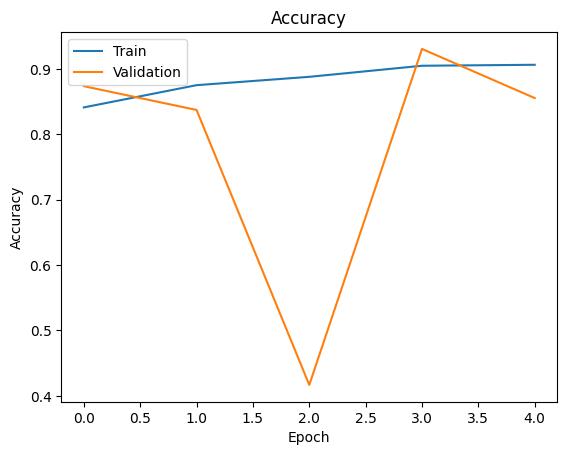

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

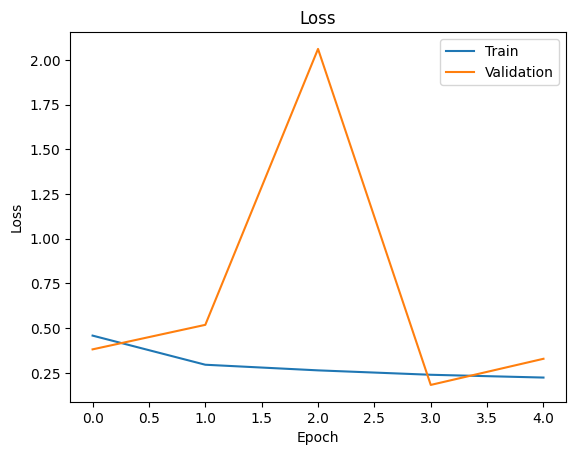

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [16]:
val_generator.reset()
pred = model.predict(val_generator)

y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

64/64 ━━━━━━━━━━━━━━━━━━━━ 396s 6s/step


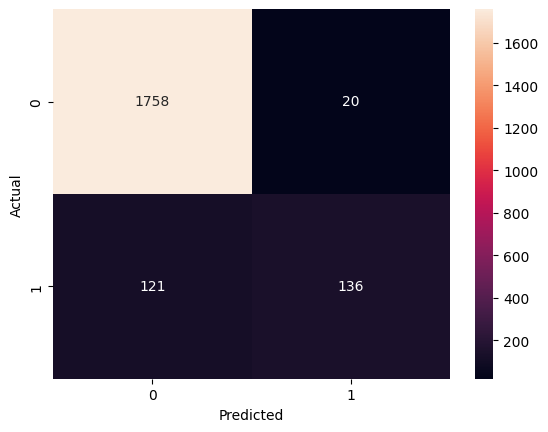

In [17]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
num_classes = train_generator.num_classes

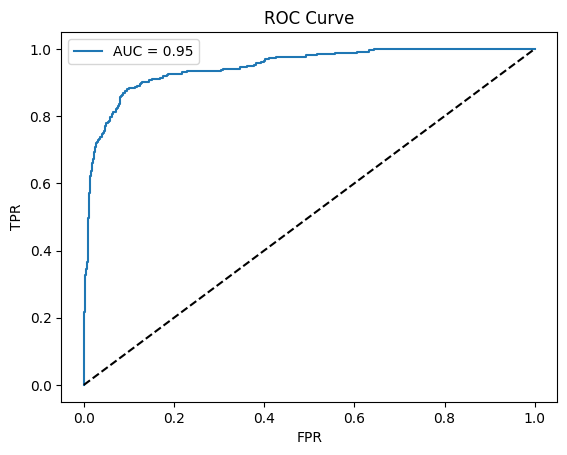

In [25]:
# ROC Curve

from sklearn.metrics import roc_curve, auc

# For binary classification only

fpr, tpr, _ = roc_curve(y_true, pred[:, 1])

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [26]:
loss, acc = model.evaluate(val_generator)
print("Final Accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 373s 6s/step - accuracy: 0.9307 - loss: 0.1824
Final Accuracy: 0.9307125210762024
